In [1]:
from pathlib import Path
import pandas as pd
import json

import sys
sys.path.append("../../utils/")

from utils import *

/home/javier/.conda/envs/tfgClean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== RUTAS =====
PROJECT_ROOT = Path.cwd().resolve().parents[2]

NOMBRE_DATASET_ENTRADA = "BCCC17__cleanning__v1"
NOMBRE_SPLIT = "BCCC17__split__v1"

RUTA_DATASET_LIMPIO = PROJECT_ROOT / "02_datasets" / "processed" / NOMBRE_DATASET_ENTRADA
RUTA_SALIDA = PROJECT_ROOT / "02_datasets" / "processed" / NOMBRE_SPLIT

NOMBRE_DATASET_LIMPIO = f"{NOMBRE_DATASET_ENTRADA}.csv"
NOMBRE_TRAIN = f"{NOMBRE_SPLIT}__train.csv"
NOMBRE_TEST = f"{NOMBRE_SPLIT}__test.csv"

NOMBRE_REPORTE = f"{NOMBRE_SPLIT}_report.json"
RUTA_REPORTE = PROJECT_ROOT / "04_experimentos" / "logs" / "resultados" / NOMBRE_SPLIT

# ===== PARÁMETROS =====
LABEL_COL = "LABEL"
TEST_SIZE = 0.20
RANDOM_STATE = 42

In [3]:
print("PROJECT_ROOT:")
print(PROJECT_ROOT)
print()

print("Dataset limpio de entrada:")
print(RUTA_DATASET_LIMPIO / NOMBRE_DATASET_LIMPIO)
print()

print("Ruta de salida:")
print(RUTA_SALIDA)

PROJECT_ROOT:
/home/javier/TFG_MODELOS_SIMPLES_MEJORADO2

Dataset limpio de entrada:
/home/javier/TFG_MODELOS_SIMPLES_MEJORADO2/02_datasets/processed/BCCC17__cleanning__v1/BCCC17__cleanning__v1.csv

Ruta de salida:
/home/javier/TFG_MODELOS_SIMPLES_MEJORADO2/02_datasets/processed/BCCC17__split__v1


In [4]:
input_path = RUTA_DATASET_LIMPIO / NOMBRE_DATASET_LIMPIO

if not input_path.exists():
    raise FileNotFoundError(f"No existe el dataset limpio en: {input_path}")

df = cargar_dataset(nombre_dataset=NOMBRE_DATASET_LIMPIO, ruta_base=RUTA_DATASET_LIMPIO)

shape_original = df.shape

print("Forma del dataset limpio:")
print(shape_original)

Forma del dataset limpio:
(1098651, 64)


In [5]:
df.head()

,DST_PORT,PROTOCOL,DURATION,PACKETS_COUNT,FWD_TOTAL_PAYLOAD_BYTES,PAYLOAD_BYTES_MAX,PAYLOAD_BYTES_MIN,PAYLOAD_BYTES_MEAN,PAYLOAD_BYTES_VARIANCE,FWD_PAYLOAD_BYTES_VARIANCE,...,BWD_SYN_FLAG_COUNTS,BWD_CWR_FLAG_COUNTS,BWD_RST_FLAG_COUNTS,PACKETS_IAT_MEAN,FWD_PACKETS_IAT_MEAN,FWD_PACKETS_IAT_STD,BWD_PACKETS_IAT_MEAN,SUBFLOW_FWD_PACKETS,SUBFLOW_FWD_BYTES,LABEL
0,53,1,0.000174,4,78,103,39,71.000000,1024.000000,0.000000,...,0,0,0,0.000058,0.000003,0.000000,0.000003,0.000000,0.000000,0
1,443,0,17.777095,21,1156,1460,0,209.428571,160789.102041,32321.719008,...,1,0,0,0.888855,1.767512,3.166228,1.963900,3.666667,385.333333,0
2,443,0,61.794042,32,700,1448,0,176.093750,162197.647461,9881.792388,...,1,0,0,1.993356,3.858970,4.870260,4.410252,2.833333,116.666667,0
3,443,0,0.435065,15,895,2702,0,446.933333,597991.928889,37483.836735,...,1,0,0,0.031076,0.072511,0.071352,0.041210,0.000000,0.000000,0
4,80,0,120.710158,38,1338,979,0,112.500000,78714.039474,24357.061224,...,1,0,0,3.262437,6.034402,4.713779,7.542984,1.400000,89.200000,0


In [6]:
if LABEL_COL not in df.columns:
    raise ValueError(f"No se encontró la columna {LABEL_COL}")

print("Columna objetivo encontrada correctamente.")
print()
print("Distribución global de clases:")
display(resumen_clases(df, LABEL_COL))

Columna objetivo encontrada correctamente.

Distribución global de clases:


,count,percentage
LABEL,,
0,450000,40.9593
1,346143,31.5062
2,161323,14.6837
3,95729,8.7133
4,9531,0.8675
5,8364,0.7613
6,6856,0.6240
7,5949,0.5415
8,5508,0.5013


In [7]:
train_df, test_df = dividir_train_test_stratified(
    df=df,
    label_col=LABEL_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Forma train:", train_df.shape)
print("Forma test:", test_df.shape)

Forma train: (878920, 64)
Forma test: (219731, 64)


In [8]:
print("Distribución de clases en TRAIN:")
display(resumen_clases(train_df, LABEL_COL))

Distribución de clases en TRAIN:


,count,percentage
LABEL,,
0,360000,40.9594
1,276914,31.5062
2,129058,14.6837
3,76583,8.7133
4,7625,0.8675
5,6691,0.7613
6,5485,0.6241
7,4759,0.5415
8,4406,0.5013


In [9]:
print("Distribución de clases en TEST:")
display(resumen_clases(test_df, LABEL_COL))

Distribución de clases en TEST:


,count,percentage
LABEL,,
0,90000,40.9592
1,69229,31.5063
2,32265,14.6839
3,19146,8.7134
4,1906,0.8674
5,1673,0.7614
6,1371,0.6239
7,1190,0.5416
8,1102,0.5015


In [10]:
resumen_global = resumen_clases(df, LABEL_COL).rename(
    columns={"count": "global_count", "percentage": "global_percentage"}
)

resumen_train = resumen_clases(train_df, LABEL_COL).rename(
    columns={"count": "train_count", "percentage": "train_percentage"}
)

resumen_test = resumen_clases(test_df, LABEL_COL).rename(
    columns={"count": "test_count", "percentage": "test_percentage"}
)

comparacion = pd.concat([resumen_global, resumen_train, resumen_test], axis=1)

print("Comparación global / train / test:")
display(comparacion)

Comparación global / train / test:


,global_count,global_percentage,train_count,train_percentage,test_count,test_percentage
LABEL,,,,,,
0,450000,40.9593,360000,40.9594,90000,40.9592
1,346143,31.5062,276914,31.5062,69229,31.5063
2,161323,14.6837,129058,14.6837,32265,14.6839
3,95729,8.7133,76583,8.7133,19146,8.7134
4,9531,0.8675,7625,0.8675,1906,0.8674
5,8364,0.7613,6691,0.7613,1673,0.7614
6,6856,0.6240,5485,0.6241,1371,0.6239
7,5949,0.5415,4759,0.5415,1190,0.5416
8,5508,0.5013,4406,0.5013,1102,0.5015


In [11]:
guardar_dataset_csv(
    df=train_df,
    nombre_archivo=NOMBRE_TRAIN,
    ruta=RUTA_SALIDA
)

guardar_dataset_csv(
    df=test_df,
    nombre_archivo=NOMBRE_TEST,
    ruta=RUTA_SALIDA
)

print("Train guardado en:")
print(RUTA_SALIDA / NOMBRE_TRAIN)
print()
print("Test guardado en:")
print(RUTA_SALIDA / NOMBRE_TEST)

Train guardado en:
/home/javier/TFG_MODELOS_SIMPLES_MEJORADO2/02_datasets/processed/BCCC17__split__v1/BCCC17__split__v1__train.csv

Test guardado en:
/home/javier/TFG_MODELOS_SIMPLES_MEJORADO2/02_datasets/processed/BCCC17__split__v1/BCCC17__split__v1__test.csv


In [12]:
reporte_split = {
    "dataset_entrada": NOMBRE_DATASET_LIMPIO,
    "label_column": LABEL_COL,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "shape_global": {
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1])
    },
    "shape_train": {
        "rows": int(train_df.shape[0]),
        "cols": int(train_df.shape[1])
    },
    "shape_test": {
        "rows": int(test_df.shape[0]),
        "cols": int(test_df.shape[1])
    },
    "class_distribution_global": {
        str(k): int(v) for k, v in df[LABEL_COL].value_counts(dropna=False).to_dict().items()
    },
    "class_distribution_train": {
        str(k): int(v) for k, v in train_df[LABEL_COL].value_counts(dropna=False).to_dict().items()
    },
    "class_distribution_test": {
        str(k): int(v) for k, v in test_df[LABEL_COL].value_counts(dropna=False).to_dict().items()
    }
}

report_path = RUTA_REPORTE / NOMBRE_REPORTE

report_path.parent.mkdir(parents=True, exist_ok=True)

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(reporte_split, f, indent=2, ensure_ascii=False)

print("Reporte guardado en:")
print(report_path)

Reporte guardado en:
/home/javier/TFG_MODELOS_SIMPLES_MEJORADO2/04_experimentos/logs/resultados/BCCC17__split__v1/BCCC17__split__v1_report.json


In [13]:
print("========== RESUMEN SPLIT ==========")
print(f"Dataset de entrada: {NOMBRE_DATASET_LIMPIO}")
print(f"Forma global: {df.shape}")
print(f"Forma train: {train_df.shape}")
print(f"Forma test: {test_df.shape}")
print(f"Test size: {TEST_SIZE}")
print(f"Random state: {RANDOM_STATE}")
print("===================================")

========== RESUMEN SPLIT ==========
Dataset de entrada: BCCC17__cleanning__v1.csv
Forma global: (1098651, 64)
Forma train: (878920, 64)
Forma test: (219731, 64)
Test size: 0.2
Random state: 42


Shape X_train numérico: (878920, 63)


K para 99.0% de varianza: 1


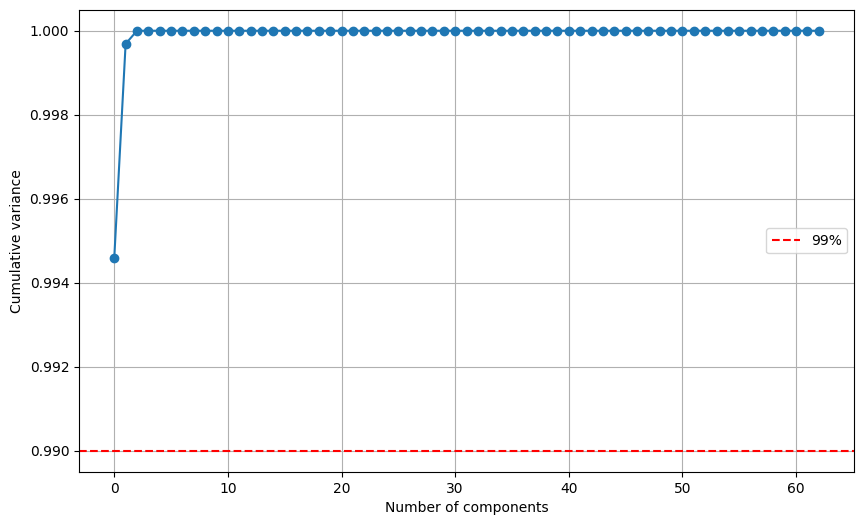

In [14]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# ===== PCA VARIANZA ACUMULADA (SOLO TRAIN) =====

# Separar X
X_train = train_df.drop(columns=[LABEL_COL])

# Solo numéricas
X_train_num = X_train.select_dtypes(include=["number"]).copy()

print("Shape X_train numérico:", X_train_num.shape)

# Escalado
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_num)

# PCA sin limitar componentes (para analizar)
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

# Varianza
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Threshold (puedes cambiarlo si quieres)
VARIANCE_THRESHOLD = 0.99

k = np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1

print(f"K para {VARIANCE_THRESHOLD*100}% de varianza:", k)

# ===== PLOT =====
plt.figure(figsize=(10, 6))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label=f'{int(VARIANCE_THRESHOLD*100)}%')

plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.grid(True)
plt.legend()

plt.savefig("pca_varianza_acumulada_standardscaler.pdf", format="pdf", bbox_inches="tight")

plt.show()

Shape X_train numérico: (878920, 63)


K para 99.0% de varianza: 1


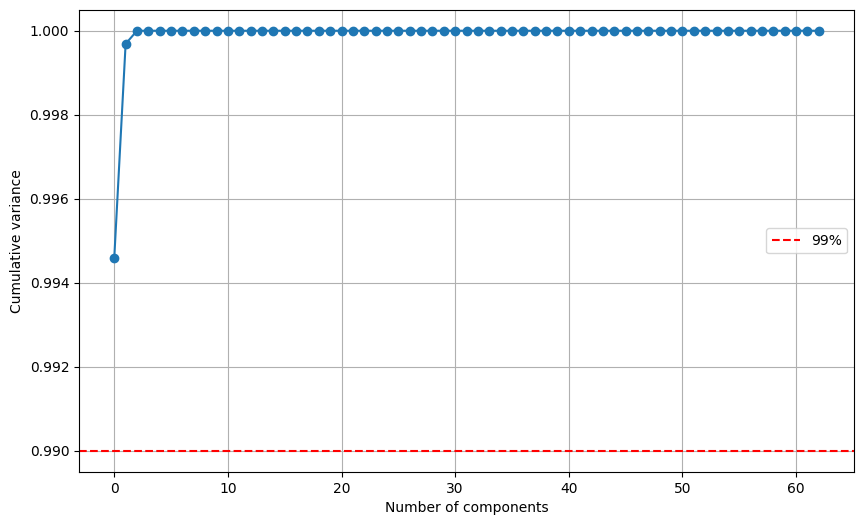

In [15]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# ===== PCA VARIANZA ACUMULADA (SOLO TRAIN) =====

# Separar X
X_train = train_df.drop(columns=[LABEL_COL])

# Solo numéricas
X_train_num = X_train.select_dtypes(include=["number"]).copy()

print("Shape X_train numérico:", X_train_num.shape)

# Escalado
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_num)

# PCA sin limitar componentes (para analizar)
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

# Varianza
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Threshold (puedes cambiarlo si quieres)
VARIANCE_THRESHOLD = 0.99

k = np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1

print(f"K para {VARIANCE_THRESHOLD*100}% de varianza:", k)

# ===== PLOT =====
plt.figure(figsize=(10, 6))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label=f'{int(VARIANCE_THRESHOLD*100)}%')

plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.grid(True)
plt.legend()

plt.savefig("pca_varianza_acumulada_robustscaler.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [16]:
from sklearn.preprocessing import RobustScaler, RobustScaler
from sklearn.decomposition import PCA
import numpy as np

def calcular_k(scaler, X, threshold=0.99):
    X_scaled = scaler.fit_transform(X)
    pca = PCA().fit(X_scaled)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    return np.argmax(cum_var >= threshold) + 1

k_standard = calcular_k(RobustScaler(), X_train_num)
k_robust = calcular_k(RobustScaler(), X_train_num)

print("K con RobustScaler:", k_standard)
print("K con RobustScaler:", k_robust)

K con RobustScaler: 1
K con RobustScaler: 1
